[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bobleesj/quantem.widget/blob/main/notebooks/show2d/show2d_simple.ipynb)
# Show2D — Quick Demo
Single images and gallery layouts with different column configurations.

In [1]:
# Install in Google Colab
try:
    import google.colab
    !pip install -q -i https://test.pypi.org/simple/ --extra-index-url https://pypi.org/simple/ quantem-widget
except ImportError:
    pass  # Not in Colab, skip

In [2]:
try:
    %load_ext autoreload
    %autoreload 2
    %env ANYWIDGET_HMR=1
except Exception:
    pass  # autoreload unavailable (Colab Python 3.12+)

env: ANYWIDGET_HMR=1


In [ ]:
import numpy as np
import torch
import quantem.widget
from quantem.widget import Show2D, profile
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
def make_hrtem(size=256, seed=0):
    """Simulate HRTEM lattice fringes with amorphous edge and shot noise."""
    rng = np.random.default_rng(seed)
    y, x = torch.meshgrid(torch.arange(size, device=device, dtype=torch.float32),
                           torch.arange(size, device=device, dtype=torch.float32), indexing="ij")
    img = torch.zeros((size, size), device=device)
    freqs = [(0.08, 0.0), (0.06, np.pi / 3), (0.10, np.pi / 6)]
    for freq, angle in freqs:
        img += torch.cos(2 * np.pi * freq * (x * np.cos(angle) + y * np.sin(angle)))
    r = torch.sqrt((x - size // 2)**2 + (y - size // 2)**2)
    envelope = 1.0 / (1 + torch.exp(-0.05 * (size // 3 - r)))
    noise = torch.from_numpy(rng.normal(0, 0.3, (size, size)).astype(np.float32)).to(device)
    img = img * envelope + noise
    return img.cpu().numpy()
# Generate a few different images
imgs = [make_hrtem(256, seed=i) for i in range(6)]
print(f"Generators ready (device={device})")
print(f"quantem.widget {quantem.widget.__version__}")
profile()

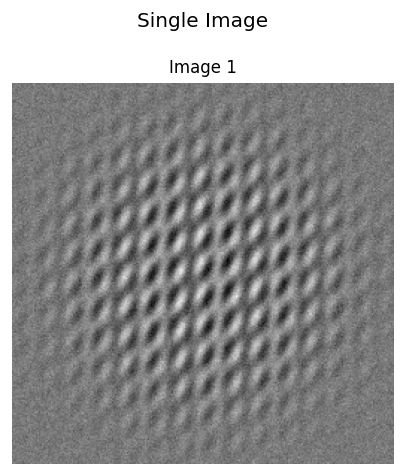

In [4]:
# Single image
Show2D(imgs[0], title="Single Image", cmap="gray")

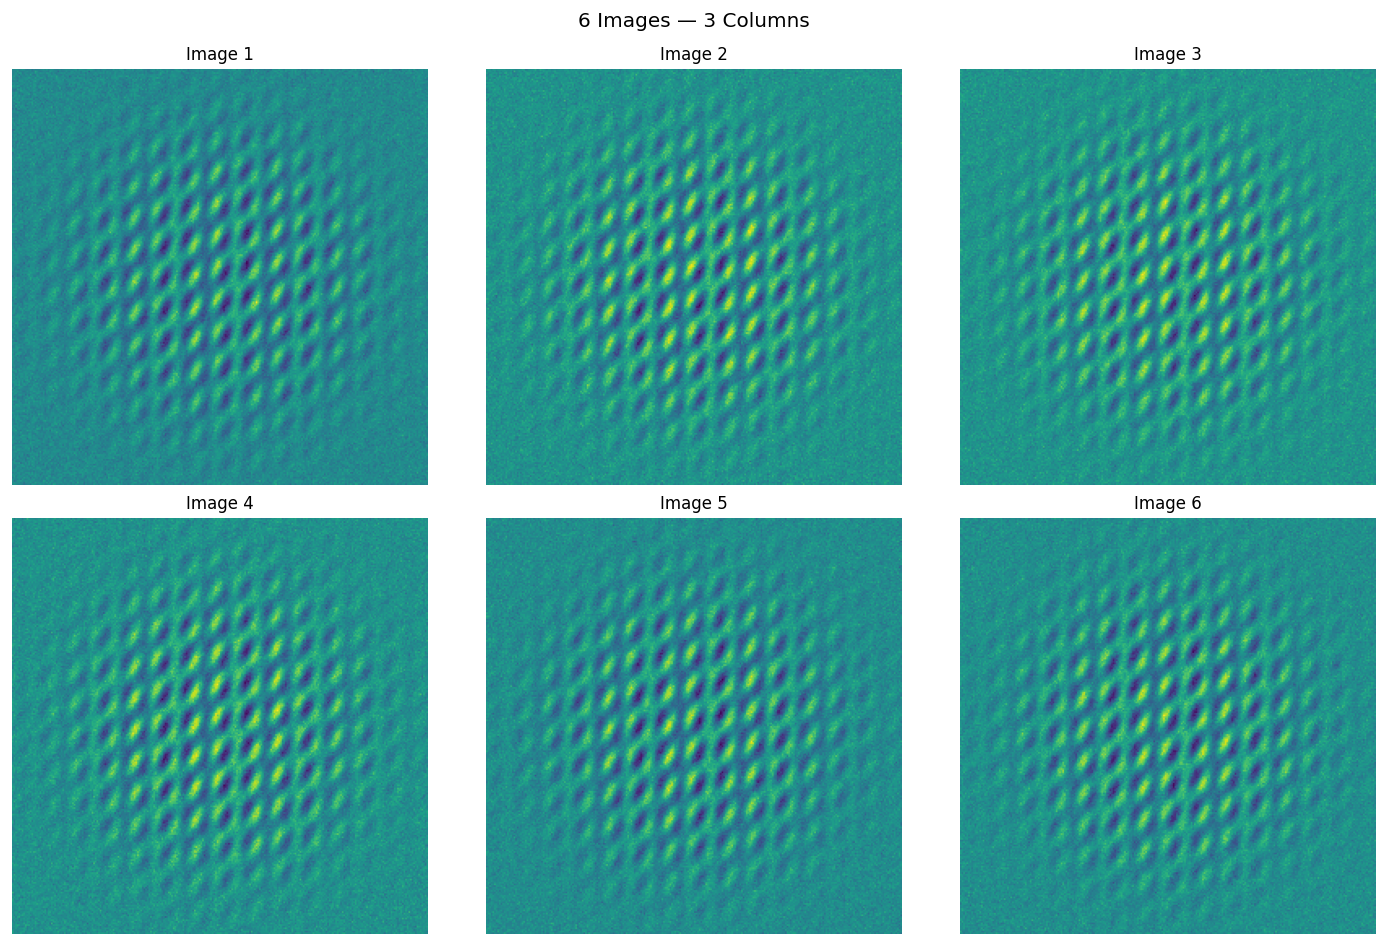

In [5]:
# 6 images, 3 columns
Show2D(imgs, title="6 Images — 3 Columns", ncols=3, cmap="viridis")

## Inspect Widget State

In [6]:
w = Show2D(imgs[0], title="Single Image", cmap="gray")
w.summary()

Single Image
════════════════════════════════
Image:    256×256
Data:     min=-3.437  max=3.831  mean=0.0009885
Display:  gray | manual contrast | linear
